In [223]:
# importando o conjunto de dados

import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

In [224]:
moradia = pd.read_csv("dataset/Housing.csv")

In [225]:
moradia.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [226]:
d = {'yes': True, 'no': False}
moradia["mainroad"].replace(d, inplace=True)
moradia["guestroom"].replace(d, inplace=True)
moradia["basement"].replace(d, inplace=True)
moradia["hotwaterheating"].replace(d, inplace=True)
moradia["airconditioning"].replace(d, inplace=True)
moradia["prefarea"].replace(d, inplace=True)
moradia['furnishingstatus'].str

In [227]:
type(moradia['furnishingstatus'][1])

str

In [228]:
moradia.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad              bool
guestroom             bool
basement              bool
hotwaterheating       bool
airconditioning       bool
parking              int64
prefarea              bool
furnishingstatus    object
dtype: object

In [229]:
moradia.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,True,False,False,False,True,2,True,furnished
1,12250000,8960,4,4,4,True,False,False,False,True,3,False,furnished
2,12250000,9960,3,2,2,True,False,True,False,False,2,True,semi-furnished
3,12215000,7500,4,2,2,True,False,True,False,True,3,True,furnished
4,11410000,7420,4,1,2,True,True,True,False,True,2,False,furnished


In [230]:
df[moradia.price <= 4340000.0]

,price,area,bedrooms,bathrooms,stories,parking
270,0.224242,0.195876,0.4,0.333333,0.666667,0.333333
271,0.224242,0.017526,0.8,0.000000,0.333333,0.000000
272,0.224242,0.166667,0.4,0.000000,0.000000,0.666667
273,0.224242,0.127148,0.6,0.000000,0.333333,0.666667
274,0.224242,0.329897,0.6,0.000000,0.333333,0.000000
...,...,...,...,...,...,...
540,0.006061,0.092784,0.2,0.000000,0.000000,0.666667
541,0.001485,0.051546,0.4,0.000000,0.000000,0.000000
542,0.000000,0.135395,0.2,0.000000,0.000000,0.000000
543,0.000000,0.086598,0.4,0.000000,0.000000,0.000000


<AxesSubplot: >

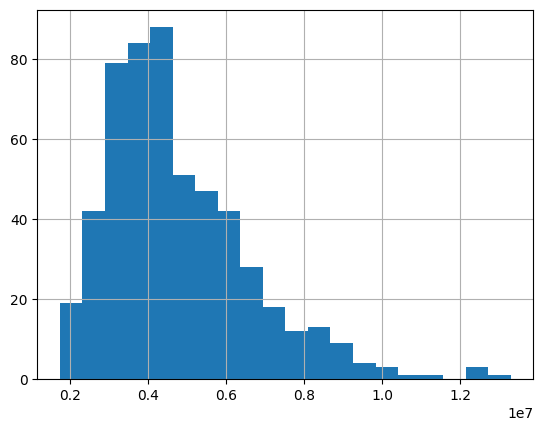

In [231]:
moradia.price.hist(bins=20)

<AxesSubplot: >

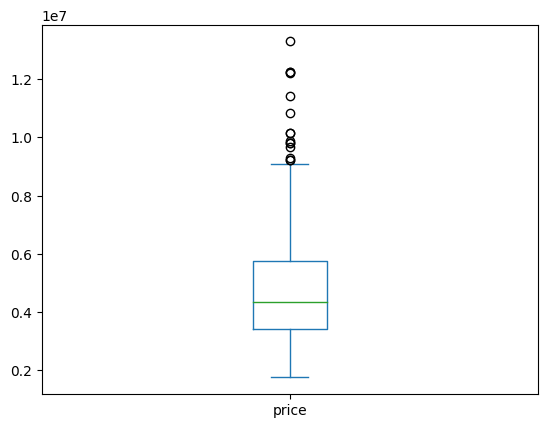

In [232]:
moradia.price.plot.box()

In [233]:
moradia[moradia.duplicated()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


<AxesSubplot: xlabel='bathrooms', ylabel='price'>

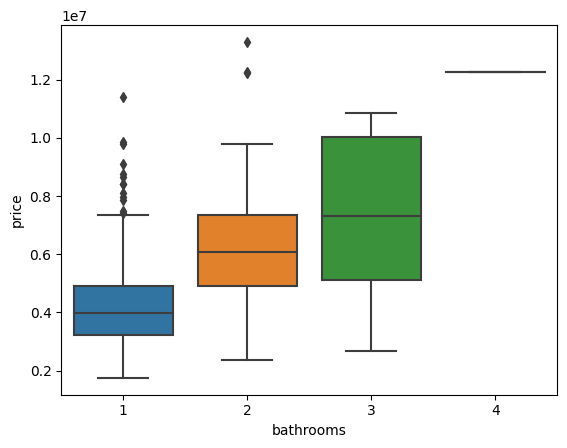

In [234]:
sns.boxplot(x='bathrooms', y='price', data=moradia)

In [235]:
moradia.bathrooms.value_counts().head()

1    401
2    133
3     10
4      1
Name: bathrooms, dtype: int64

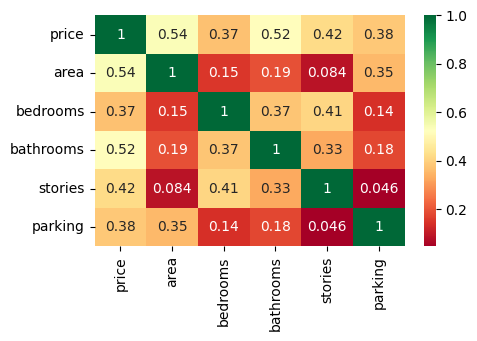

In [277]:
fig, ax = plt.subplots(figsize=(5,3))
sns.heatmap(moradia.corr(numeric_only = True),annot=True, cmap='RdYlGn')
plt.show()

In [237]:
moradia.corr(numeric_only = True)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382


In [238]:
moradia.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,True,False,False,False,True,2,True,furnished
1,12250000,8960,4,4,4,True,False,False,False,True,3,False,furnished
2,12250000,9960,3,2,2,True,False,True,False,False,2,True,semi-furnished
3,12215000,7500,4,2,2,True,False,True,False,True,3,True,furnished
4,11410000,7420,4,1,2,True,True,True,False,True,2,False,furnished


<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.


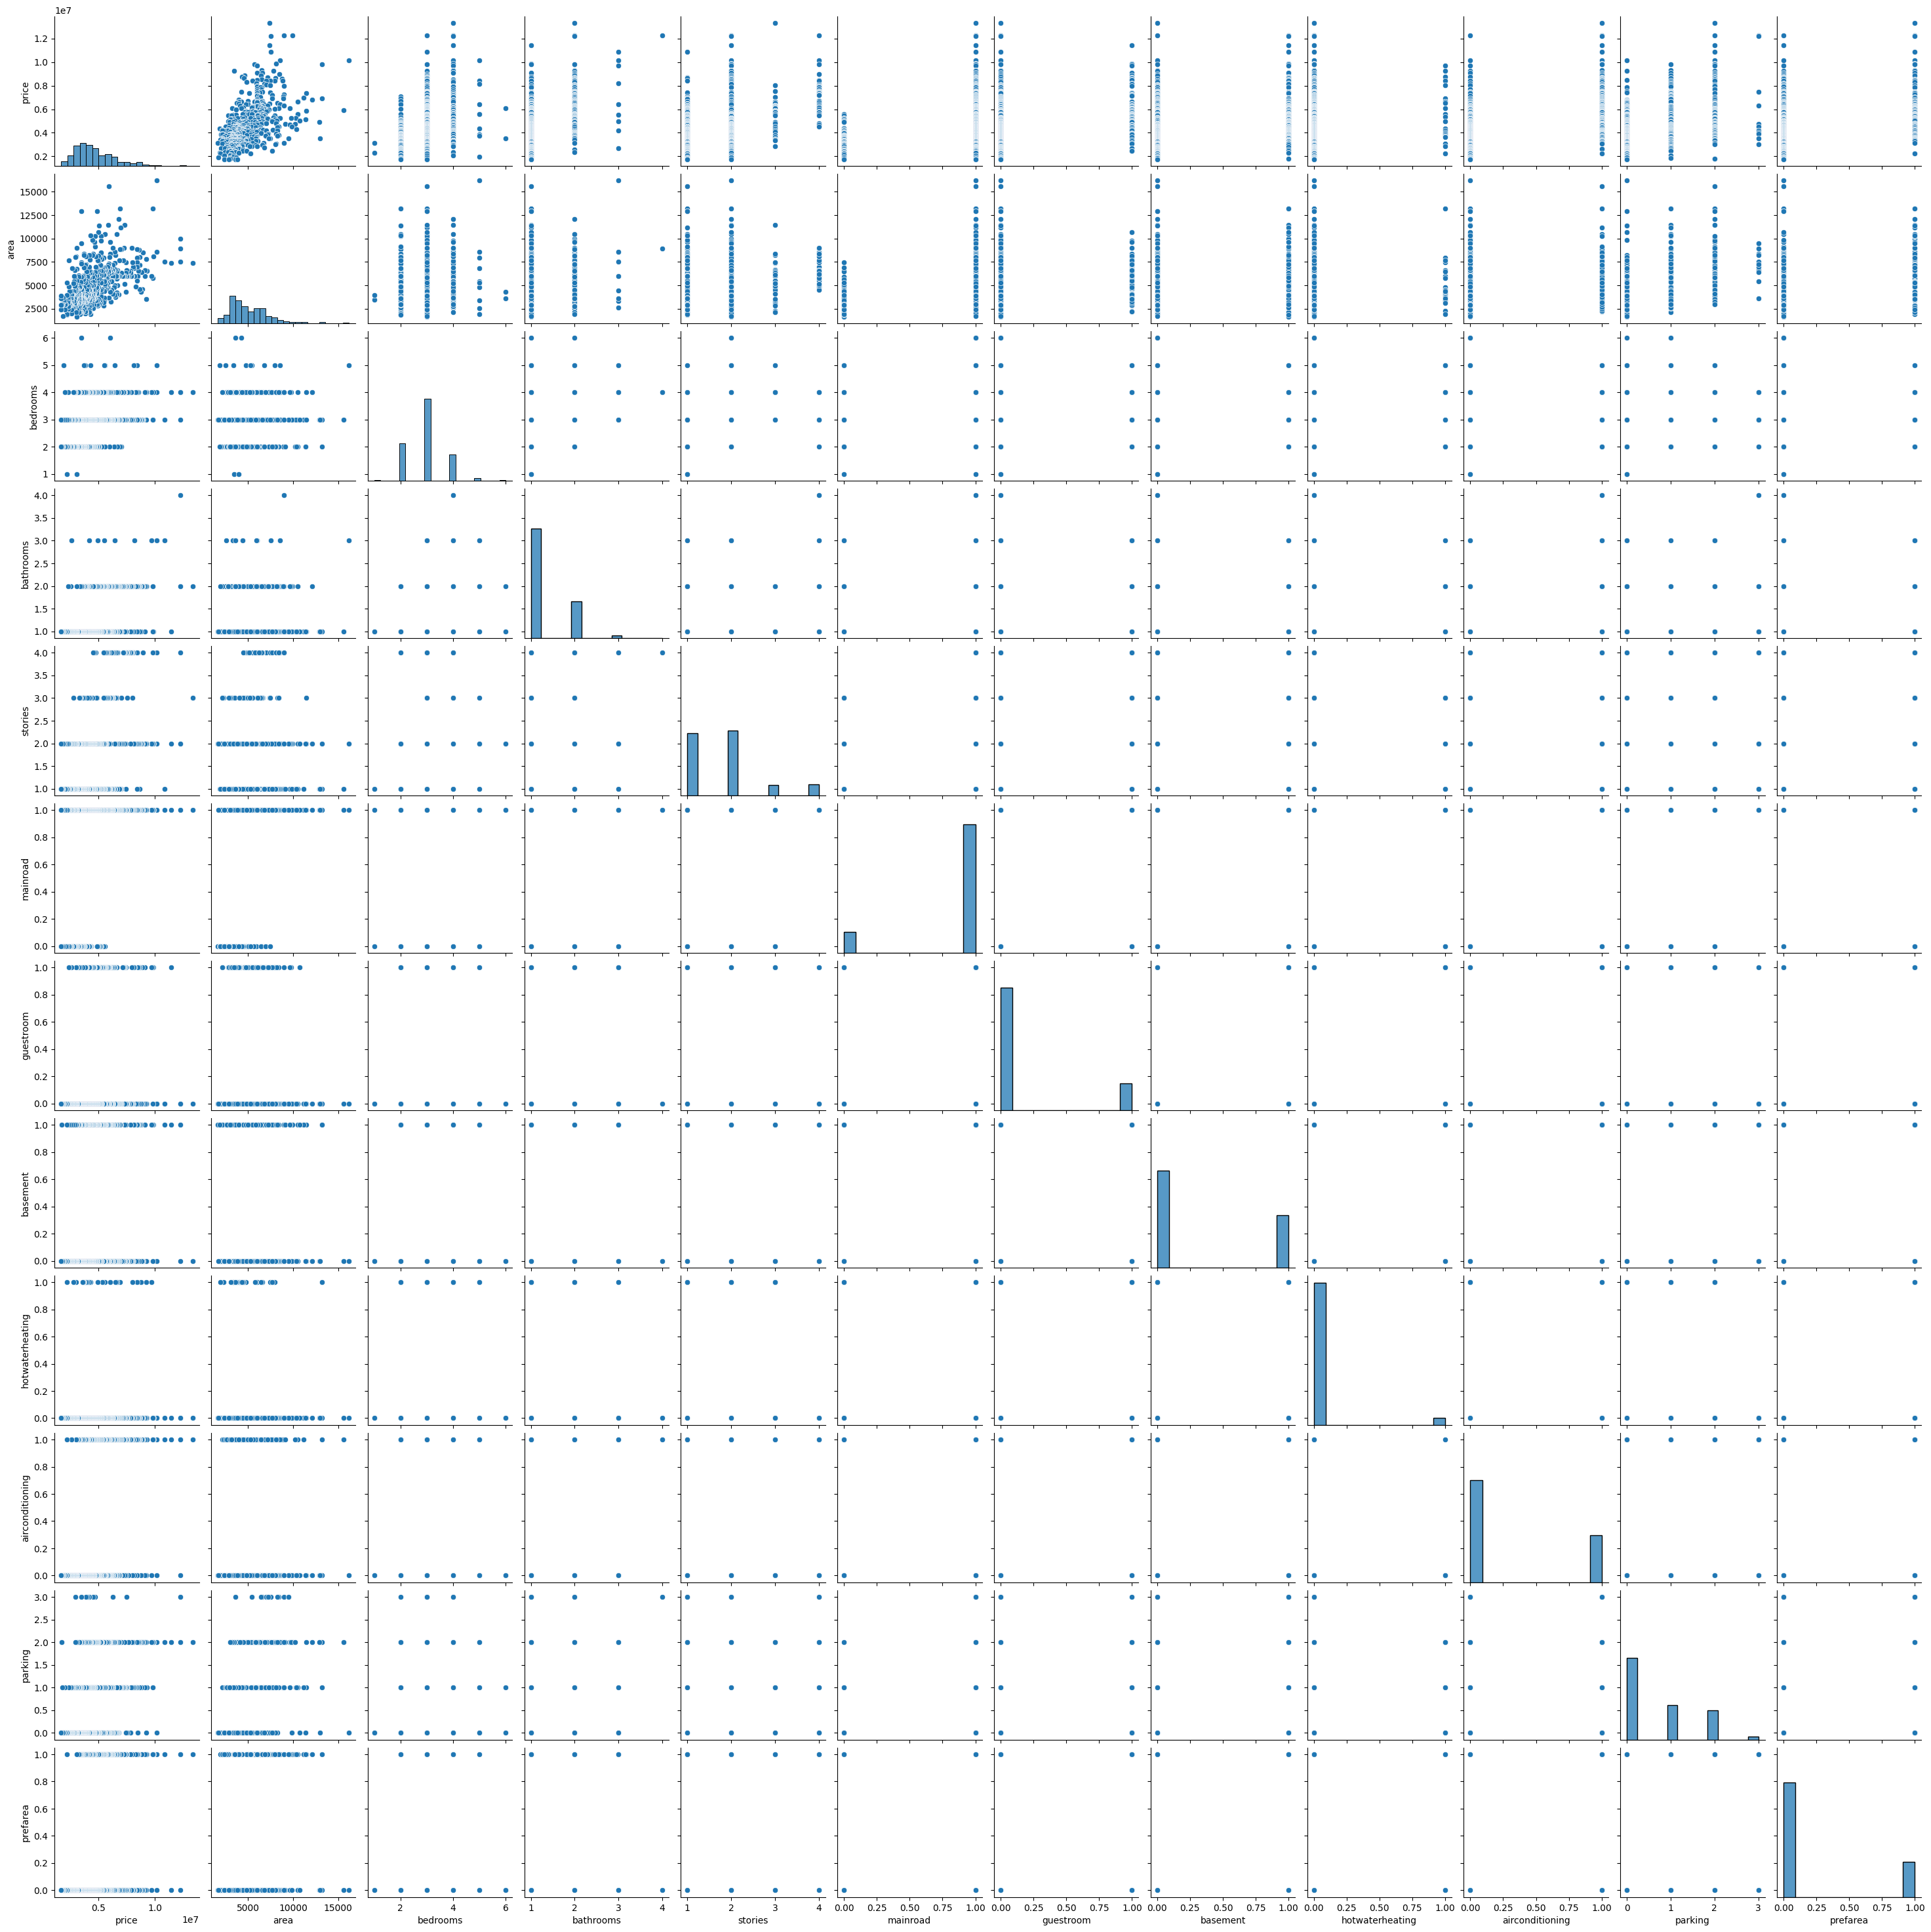

In [239]:
sns.pairplot(moradia)

In [240]:
moradia[moradia.area == moradia.area.max()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,True,False,False,False,False,0,False,unfurnished


In [241]:
moradia[moradia.price == moradia.price.max()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,True,False,False,False,True,2,True,furnished


In [242]:
moradia['preco_area'] = round(moradia.price/moradia.area)

In [243]:
moradia.preco_area.value_counts()

997.0     5
803.0     4
895.0     4
1191.0    3
944.0     3
         ..
1049.0    1
1424.0    1
838.0     1
448.0     1
455.0     1
Name: preco_area, Length: 422, dtype: int64

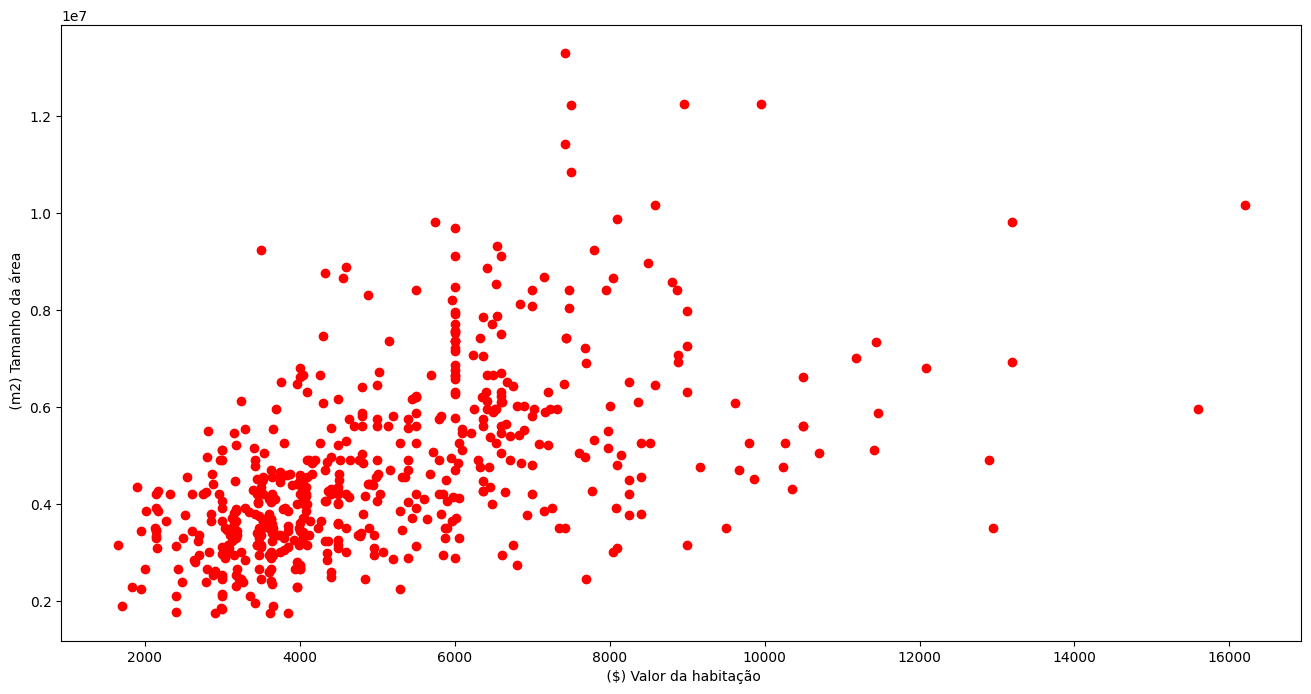

In [244]:
plt.figure(figsize = (16,8))
plt.scatter(
    moradia['area'], 
    moradia['price'], 
    c='red')
plt.ylabel(" (m2) Tamanho da área")
plt.xlabel(" ($) Valor da habitação")
plt.show()

In [245]:
X = moradia['area'].values.reshape(-1,1)
y = moradia['price'].values.reshape(-1,1)


reg = LinearRegression()
reg.fit(X, y)


print("O modelo é: Preço = {:.5} + {:.5}X".format(reg.intercept_[0], reg.coef_[0][0]))

O modelo é: Preço = 2.3873e+06 + 461.97X


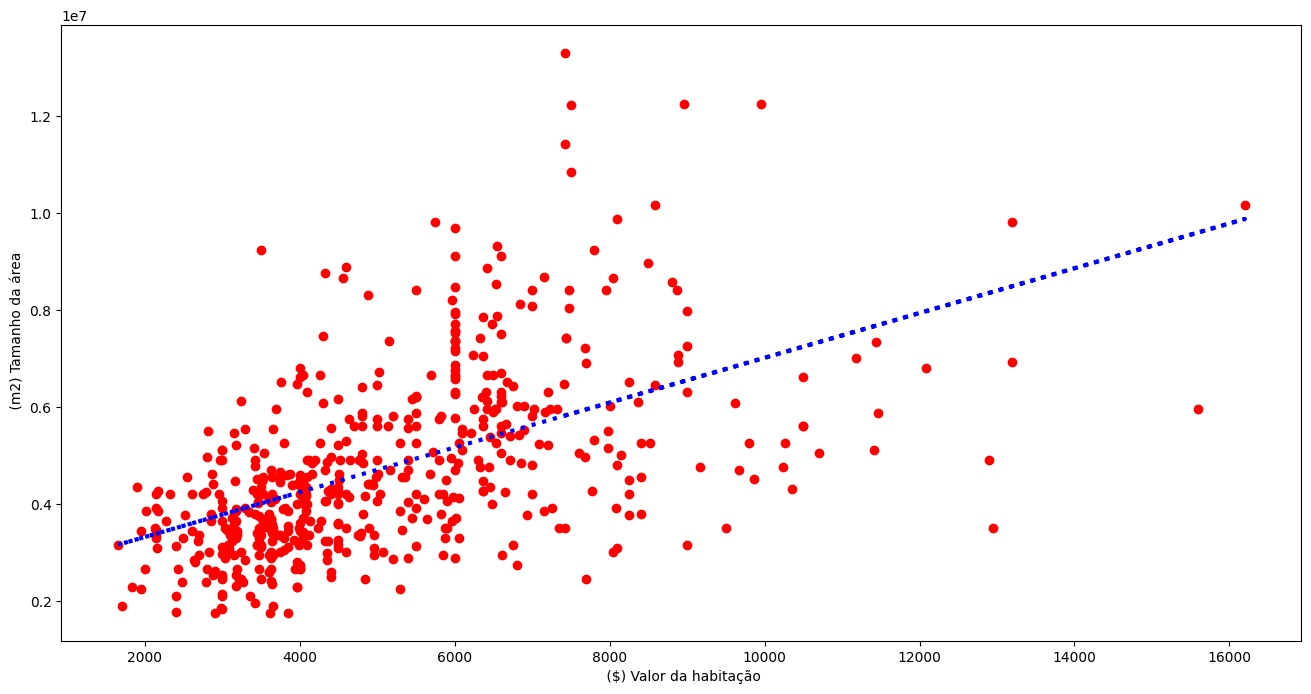

In [246]:
f_previsaoes = reg.predict(X)

plt.figure(figsize = (16,8))
plt.scatter(
    moradia['area'], 
    moradia['price'], 
    c='red')


plt.plot(
    moradia['area'], 
    f_previsaoes,
    c='blue',
    linewidth=3,
    linestyle=':'
)

plt.xlabel(" ($) Valor da habitação")
plt.ylabel(" (m2) Tamanho da área")
plt.show()

In [247]:
X = moradia['area']
y = moradia['price']
X2 = sm.add_constant(X)
est = sm.OLS(y, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     218.9
Date:                Thu, 15 Dec 2022   Prob (F-statistic):           7.39e-42
Time:                        14:39:04   Log-Likelihood:                -8551.2
No. Observations:                 545   AIC:                         1.711e+04
Df Residuals:                     543   BIC:                         1.712e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.387e+06   1.74e+05     13.681      0.0

# Regressão Linear Multipla

In [248]:
# Selecionando e carregando os dados
colunas_selecionadas = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
moradia = pd.read_csv("dataset/Housing.csv", usecols=colunas_selecionadas)

In [249]:
type(moradia)

pandas.core.frame.DataFrame

In [250]:
# olhando os tipos dos dados

moradia.dtypes

price        int64
area         int64
bedrooms     int64
bathrooms    int64
stories      int64
parking      int64
dtype: object

In [251]:
# visualizando as primeiras linhas

moradia.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


In [252]:
# visualizando as últimas linhas

moradia.tail(9)

,price,area,bedrooms,bathrooms,stories,parking
536,1960000,3420,5,1,2,0
537,1890000,1700,3,1,2,0
538,1890000,3649,2,1,1,0
539,1855000,2990,2,1,1,1
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0
544,1750000,3850,3,1,2,0


In [253]:
moradia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   price      545 non-null    int64
 1   area       545 non-null    int64
 2   bedrooms   545 non-null    int64
 3   bathrooms  545 non-null    int64
 4   stories    545 non-null    int64
 5   parking    545 non-null    int64
dtypes: int64(6)
memory usage: 25.7 KB


In [254]:
moradia.isnull().sum()

price        0
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64

In [255]:
# verificando as dimensões

moradia.shape

(545, 6)

In [256]:
# analisando as principais estatísticas

moradia.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [257]:
# fazendo uma transposição das principais estatísticas

moradia.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [258]:
df = moradia.copy()

In [259]:
df.price.min()

1750000

In [260]:
# Escaler para as variaveis do eixo X
scaler_x = MinMaxScaler()
features_selected = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df[features_selected] = scaler_x.fit_transform(df[features_selected])
df.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,0.396564,0.6,0.333333,0.666667,0.666667
1,12250000,0.502405,0.6,1.000000,1.000000,1.000000
2,12250000,0.571134,0.4,0.333333,0.333333,0.666667
3,12215000,0.402062,0.6,0.333333,0.333333,1.000000
4,11410000,0.396564,0.6,0.000000,0.333333,0.666667


In [261]:
# Escaler para as variaveis do eixo Y (Preço)
scaler_y = MinMaxScaler()
df[['price']]  = scaler_y.fit_transform(df[['price']])
df.head() # Exibe os dados escalonados

,price,area,bedrooms,bathrooms,stories,parking
0,1.000000,0.396564,0.6,0.333333,0.666667,0.666667
1,0.909091,0.502405,0.6,1.000000,1.000000,1.000000
2,0.909091,0.571134,0.4,0.333333,0.333333,0.666667
3,0.906061,0.402062,0.6,0.333333,0.333333,1.000000
4,0.836364,0.396564,0.6,0.000000,0.333333,0.666667


In [262]:
# Separa as colunas que serão utilizadas para a análise preditiva
feature_columns = df.drop('price', axis=1)
feature_columns.head()

,area,bedrooms,bathrooms,stories,parking
0,0.396564,0.6,0.333333,0.666667,0.666667
1,0.502405,0.6,1.000000,1.000000,1.000000
2,0.571134,0.4,0.333333,0.333333,0.666667
3,0.402062,0.6,0.333333,0.333333,1.000000
4,0.396564,0.6,0.000000,0.333333,0.666667


In [263]:
# separa a coluna que contém o resultado conhecido e que podemos utilizar para validar o modelo (variavel dependente)
price_column = df.price
price_column.head()

0    1.000000
1    0.909091
2    0.909091
3    0.906061
4    0.836364
Name: price, dtype: float64

### A seguir irei montar a logica de predição com TensorFlow para chegar à predição

In [264]:
# Criando as Features Columns do tipo Numeric no TensorFlow para cada coluna preditora
tf_columns = [tf.feature_column.numeric_column(key = c) for c in features_selected]
print('Lista de features TensorFlow:\r')
for c in tf_columns:
    print(c)

Lista de features TensorFlow:
NumericColumn(key='area', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)
NumericColumn(key='bedrooms', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)
NumericColumn(key='bathrooms', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)
NumericColumn(key='stories', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)
NumericColumn(key='parking', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)


In [265]:
# fazendo a divisão dos dados entre treinamento e teste
features_train, features_test, price_train, price_test = train_test_split(feature_columns, price_column, test_size = 0.3)
print('Quantidade de registros de treinamento: ' + str(features_train.shape[0]))
print('Quantidade de registros de teste: ' + str(features_test.shape[0]))

Quantidade de registros de treinamento: 381
Quantidade de registros de teste: 164


In [266]:
# definindo as funções de treinamento e teste usando Estimator do TensorFlow
train_function = tf.compat.v1.estimator.inputs.pandas_input_fn(x = features_train, y = price_train, batch_size = 32, num_epochs = None, shuffle = True)
test_function = tf.compat.v1.estimator.inputs.pandas_input_fn(x = features_test, y = price_test, batch_size = 32, num_epochs = 10000, shuffle = True)
regressor = tf.compat.v1.estimator.LinearRegressor(feature_columns = tf_columns)

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': 'C:\\Users\\thimorae\\AppData\\Local\\Temp\\tmpm3f2r2ur', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


In [267]:
# executar o treinamento do modelo
regressor.train(input_fn=train_function, steps=10000)

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Create CheckpointSaverHook.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
INFO:tensorflow:Calling checkpoint listeners before saving checkpoint 0...
INFO:tensorflow:Saving checkpoints for 0 into C:\Users\thimorae\AppData\Local\Temp\tmpm3f2r2ur\model.ckpt.
INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 0...
INFO:tensorflow:loss = 1.7068124, step = 0
INFO:tensorflow:global_step/sec: 861.922
INFO:tensorflow:loss = 0.3152226, step = 100 (0.119 sec)
INFO:tensorflow:global_step/sec: 1085.68
INFO:tensorflow:loss = 0.4846025, step = 200 (0.092 sec)
INFO:tensorflow:global_step/sec: 1183.18
INFO:tensorflow:loss = 0.28414452, step = 300 (0.084 sec)
INFO:tensorflow:global_step/sec: 1208.29
INFO:tensorflow:loss = 0.31890327, step = 400 (0.084 sec)
INFO:tensorflow:global_step/sec: 1224.48
INFO:tensorflow:loss = 0.3822

In [268]:
# obtendo as métricas do treinamento
train_metrics = regressor.evaluate(input_fn=train_function, steps=10000)
train_metrics

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Starting evaluation at 2022-12-15T14:39:14
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\thimorae\AppData\Local\Temp\tmpm3f2r2ur\model.ckpt-10000
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
INFO:tensorflow:Evaluation [1000/10000]
INFO:tensorflow:Evaluation [2000/10000]
INFO:tensorflow:Evaluation [3000/10000]
INFO:tensorflow:Evaluation [4000/10000]
INFO:tensorflow:Evaluation [5000/10000]
INFO:tensorflow:Evaluation [6000/10000]
INFO:tensorflow:Evaluation [7000/10000]
INFO:tensorflow:Evaluation [8000/10000]
INFO:tensorflow:Evaluation [9000/10000]
INFO:tensorflow:Evaluation [10000/10000]
INFO:tensorflow:Inference Time : 6.51776s
INFO:tensorflow:Finished evaluation at 2022-12-15-14:39:21
INFO:tensorflow:Saving dict for global step 10000: average_loss = 0.0106693795, global_step = 10000, label/mean = 0.2595896, loss = 0.3414

{'average_loss': 0.0106693795,
 'label/mean': 0.2595896,
 'loss': 0.34142014,
 'prediction/mean': 0.2579984,
 'global_step': 10000}

In [269]:
# obtendo as metricas do teste
test_metrics = regressor.evaluate(input_fn=test_function, steps=10000)
test_metrics

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Starting evaluation at 2022-12-15T14:39:21
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\thimorae\AppData\Local\Temp\tmpm3f2r2ur\model.ckpt-10000
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.
INFO:tensorflow:Evaluation [1000/10000]
INFO:tensorflow:Evaluation [2000/10000]
INFO:tensorflow:Evaluation [3000/10000]
INFO:tensorflow:Evaluation [4000/10000]
INFO:tensorflow:Evaluation [5000/10000]
INFO:tensorflow:Evaluation [6000/10000]
INFO:tensorflow:Evaluation [7000/10000]
INFO:tensorflow:Evaluation [8000/10000]
INFO:tensorflow:Evaluation [9000/10000]
INFO:tensorflow:Evaluation [10000/10000]
INFO:tensorflow:Inference Time : 6.67885s
INFO:tensorflow:Finished evaluation at 2022-12-15-14:39:27
INFO:tensorflow:Saving dict for global step 10000: average_loss = 0.01355647, global_step = 10000, label/mean = 0.26490754, loss = 0.43380

{'average_loss': 0.01355647,
 'label/mean': 0.26490754,
 'loss': 0.43380705,
 'prediction/mean': 0.25601634,
 'global_step': 10000}

In [270]:
# criando a previsão
predict_function = tf.compat.v1.estimator.inputs.pandas_input_fn(x = features_test, shuffle=False)
predictions = regressor.predict(input_fn=predict_function)
list(predictions)[:10]

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\thimorae\AppData\Local\Temp\tmpm3f2r2ur\model.ckpt-10000
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.


[{'predictions': array([0.14233321], dtype=float32)},
 {'predictions': array([0.16302507], dtype=float32)},
 {'predictions': array([0.24695428], dtype=float32)},
 {'predictions': array([0.1618076], dtype=float32)},
 {'predictions': array([0.18361941], dtype=float32)},
 {'predictions': array([0.4521572], dtype=float32)},
 {'predictions': array([0.4288966], dtype=float32)},
 {'predictions': array([0.19569643], dtype=float32)},
 {'predictions': array([0.11551771], dtype=float32)},
 {'predictions': array([0.25249702], dtype=float32)}]

In [271]:
prediction_values = []
for p in regressor.predict(input_fn=predict_function):
    prediction_values.append(p['predictions'])
prediction_values[:10]

INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from C:\Users\thimorae\AppData\Local\Temp\tmpm3f2r2ur\model.ckpt-10000
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.


[array([0.14233321], dtype=float32),
 array([0.16302507], dtype=float32),
 array([0.24695428], dtype=float32),
 array([0.1618076], dtype=float32),
 array([0.18361941], dtype=float32),
 array([0.4521572], dtype=float32),
 array([0.4288966], dtype=float32),
 array([0.19569643], dtype=float32),
 array([0.11551771], dtype=float32),
 array([0.25249702], dtype=float32)]

In [272]:
# Transformado os dados de volta para a escala original dos valores
prediction_values = np.asarray(prediction_values).reshape(-1,1) # coloca em formato de matriz
prediction_values = scaler_y.inverse_transform(prediction_values)
prediction_values[:10]

array([[3393948.5],
       [3632939.5],
       [4602322. ],
       [3618877.8],
       [3870804.2],
       [6972415.5],
       [6703755.5],
       [4010293.8],
       [3084229.5],
       [4666340.5]], dtype=float32)

In [273]:
# Preparando os dados para comparar
price_test_matrix = price_test.values.reshape(-1,1) # transformando o array para matriz
price_test_matrix = scaler_y.inverse_transform(price_test_matrix) # voltando os valores para a escala original
price_test_matrix[:10]

array([[2100000.],
       [4900000.],
       [6107500.],
       [4515000.],
       [2653000.],
       [6195000.],
       [8540000.],
       [3465000.],
       [3745000.],
       [4060000.]])

In [274]:
# medindo a qualidade do algoritmo treinado
mean = mean_absolute_error(price_test_matrix, prediction_values)
mean

990883.3338414634

## Referências

- [Kaggle](https://www.kaggle.com/code/rafaelleonhardt/house-prices-regress-o-linear-multipla-estimators) - House Prices: Regressão Linear Multipla Estimators
- [Linkedin](https://pt.linkedin.com/pulse/regress%C3%A3o-linear-simples-e-m%C3%BAltipla-em-python-100-pr%C3%A1tico-santos) - Regressão linear Simples e Múltipla em Python - 100% prático